# Tutorial 4 — MOSAIC mode: HIP64892 B

**What you'll learn:** How to combine a medium-resolution spectrum and multi-band photometry into a single simultaneous fit using ForMoSA's MOSAIC mode.

**Target:** HIP64892 B is bright brown dwarf companion at ~125 pc, discovered in SHINE survey by Cheethal at el 2018. 

**Data:** We will use the VLTI/GRAVITY, VLT/SPHERE and VLT/NaCo data. These observations were published in [A. Cheetham et al. (2018)](https://www.aanda.org/articles/aa/pdf/2018/07/aa32650-18.pdf) and [J. Kammerer et al. (2025)](https://www.aanda.org/articles/aa/pdf/2025/12/aa56860-25.pdf).

**MOSAIC mode:** Each instrument/dataset gets its own likelihood. ForMoSA computes a *meta-likelihood* (sum of individual log-likelihoods) and fits a per-instrument analytical scaling factor (alpha_i) to account for flux calibration offsets between different instruments.

**Parameters fitted:** Teff, log g, r, d, rv, alpha_0 (spectrum), alpha_1 (photometry)

**Grid:** ATMO

## Section 0: Setup

In [3]:
import sys
try:
    import ForMoSA
    print(f"ForMoSA {ForMoSA.__version__} — OK")
except ImportError:
    raise ImportError("pip install ForMoSA && conda install dask netCDF4 bottleneck")
print(f"Python {sys.version.split()[0]}")


ForMoSA 2.0.0 — OK
Python 3.11.13


In [4]:
from pathlib import Path
TUTORIAL_DIR = Path(".").resolve()
for d in ["data", "adapted_grid", "results", "grid"]:
    (TUTORIAL_DIR / d).mkdir(exist_ok=True)
print(f"Working directory: {TUTORIAL_DIR}")


Working directory: /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/mosaic/hip64892b


In [10]:
from astropy.io import fits

SPEC_FILE  = TUTORIAL_DIR / "data" / "2_HIP64892B_GRAVITY_roman_prep.fits"
PHOTO_FILE = TUTORIAL_DIR / "data" / "0_HIP64892B_photo_Paranal_NACO_Lp.fits"

# Validate required data keys. Support two FITS layouts:
# 1) Multiple HDUs named WAV/FLX/ERR/...
# 2) A single BINTable HDU with columns WAV/FLX/ERR/...
for label, fpath, required in [
    ("Spectrum",  SPEC_FILE,  {"WAV", "WAVE_UNIT", "FLX", "ERR", "RES"}),
    ("Photometry", PHOTO_FILE, {"WAV", "WAVE_UNIT", "FLX", "ERR", "FAC", "INS", "FILT"}),
    ]:
    with fits.open(fpath) as hdul:
        ext_names = {hdu.name.upper() for hdu in hdul[1:] if getattr(hdu, "name", None)}

        # Find first table HDU with columns, if any
        table_hdu = next(
            (hdu for hdu in hdul[1:] if hasattr(hdu, "columns") and hdu.columns is not None),
            None,
        )
        table_cols = ({name.upper() for name in table_hdu.columns.names} if table_hdu is not None else set())

    # Prefer table-column validation when present; otherwise validate extension names
    available = table_cols if table_cols else ext_names
    missing = required - available
    if missing:
        mode = "table columns" if table_cols else "FITS extensions"
        print(
            f"Missing required {mode}: {sorted(missing)}. "
            f"Found: {sorted(available)}"
        )

    print("\nValidation source:", "BINTable columns" if table_cols else "FITS extensions")
    print("Required keys (marked ✓):")
    for name in sorted(available):
        mark = "✓" if name in required else " "
        print(f"  {mark} {name}")
    print("\nAll required keys present — data is valid.")



Missing required table columns: ['ERR', 'WAVE_UNIT']. Found: ['COV', 'FLX', 'INS', 'RES', 'WAV']

Validation source: BINTable columns
Required keys (marked ✓):
    COV
  ✓ FLX
    INS
  ✓ RES
  ✓ WAV

All required keys present — data is valid.
Missing required table columns: ['FAC', 'FILT', 'WAVE_UNIT']. Found: ['ERR', 'FACILITY', 'FILTER_ID', 'FLX', 'INS', 'RES', 'WAV']

Validation source: BINTable columns
Required keys (marked ✓):
  ✓ ERR
    FACILITY
    FILTER_ID
  ✓ FLX
  ✓ INS
    RES
  ✓ WAV

All required keys present — data is valid.


In [12]:
# Grid download
# The ATMO R=3000 grid is ~900 MB. Once downloaded, keep it —
# it works for all ForMoSA tutorials and your own science.
import urllib.request

GRID_FILE = TUTORIAL_DIR / "grid" / "ATMO_R3000.nc"
GRID_URL  = "https://drive.usercontent.google.com/download?id=1XDtMzvB0kU_gvCrNwtS0nEkFZX4OrQmK&export=download&confirm=t"

# Override GRID_FILE here if you already have the grid elsewhere:
# GRID_FILE = Path("/path/to/your/ATMO_R3000.nc")

if not GRID_FILE.exists():
    print("Downloading ATMO model grid (~900 MB). This takes a few minutes.\n")
    try:
        from tqdm import tqdm
        class _Progress(tqdm):
            def update_to(self, b=1, bs=1, ts=None):
                if ts: self.total = ts
                self.update(b * bs - self.n)
        with _Progress(unit="B", unit_scale=True, desc="ATMO_R3000.nc") as t:
            urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=t.update_to)
    except ImportError:
        def _progress(count, bs, total):
            pct = min(100, count * bs / total * 100)
            print(f"\r  {pct:.1f}%  {count*bs/1e6:.1f}/{total/1e6:.1f} MB",
                  end="", flush=True)
        urllib.request.urlretrieve(GRID_URL, GRID_FILE, reporthook=_progress)
        print()
    print(f"\nSaved: {GRID_FILE}")
else:
    print(f"Grid already present: {GRID_FILE.name}")

import xarray as xr
grid = xr.open_dataset(GRID_FILE, decode_cf=False)
par_names = grid.attrs.get("par", [])
par_units = grid.attrs.get("unit", [])
print(f"\nGrid dimensions: {dict(grid.sizes)}")
for i, (key, name, unit) in enumerate(zip(["par1", "par2", "par3", "par4", "par5"],
                                           par_names or ["par1","par2","par3","par4","par5"],
                                           par_units or ["","","","",""])):
    if key in grid.coords:
        vals = grid[key].values
        print(f"  {name} {unit}: {vals[0]:.1f} → {vals[-1]:.1f}  ({len(vals)} points)")

# Display the grid content in a notebook
# Click on the data repo icon (on the right) to show the full content if needed
grid

ATMO_R3000.nc: 871MB [00:22, 39.5MB/s]                            



Saved: /Users/rajpoot/Karmabhumi/Packages/ForMoSA/docs/tutorials/mosaic/hip64892b/grid/ATMO_R3000.nc

Grid dimensions: {'wavelength': 15031, 'par1': 23, 'par2': 7, 'par3': 5, 'par4': 3, 'par5': 3}
  teff (K): 800.0 → 3000.0  (23 points)
  logg (dex): 2.5 → 5.5  (7 points)
  mh : -0.6 → 0.6  (5 points)
  co : 0.3 → 0.7  (3 points)
  gamma : 1.0 → 1.1  (3 points)


<xarray.Dataset>
Dimensions:     (wavelength: 15031, par1: 23, par2: 7, par3: 5, par4: 3, par5: 3)
Coordinates:
  * wavelength  (wavelength) float64 0.2 0.2001 0.2002 ... 29.98 29.99 29.99
  * par1        (par1) float64 800.0 900.0 1e+03 ... 2.8e+03 2.9e+03 3e+03
  * par2        (par2) float64 2.5 3.0 3.5 4.0 4.5 5.0 5.5
  * par3        (par3) float64 -0.6 -0.3 0.0 0.3 0.6
  * par4        (par4) float64 0.3 0.55 0.7
  * par5        (par5) float64 1.01 1.03 1.05
Data variables:
    grid        (wavelength, par1, par2, par3, par4, par5) float64 ...
Attributes:
    key:      ['par1', 'par2', 'par3', 'par4', 'par5']
    par:      ['teff', 'logg', 'mh', 'co', 'gamma']
    title:    ['Teff', 'log(g)', '[M/H]', 'C/O', 'gamma']
    unit:     ['(K)', '(dex)', '', '', '']
    res:      [3000. 3000. 3000. ... 3000. 3000. 3000.]

## Section 1: The science

### What is MOSAIC mode?

MOSAIC mode allows you to fit **multiple datasets simultaneously** with a single
nested sampling run. Each dataset gets its own likelihood:

```
log L_total = log L_spectrum + log L_photometry
```

ForMoSA also fits a per-dataset **analytical scaling factor** (alpha_i) that
accounts for intercalibration offsets between different instruments —
for example, a 10% offset between a ground-based spectrum and space photometry.
This makes the fit robust to absolute flux calibration uncertainties.

### When to use MOSAIC

Use MOSAIC when you have:
- Observations from different instruments with different resolutions
- Potential flux calibration offsets between datasets
- More data than a single observation provides

**Pitfall:** Too many alpha parameters with too few data points leads to
overfitting. Rule of thumb: you need at least ~10× more data points than
free alpha parameters.

### HIP 64892 B

HIP 64892 B is a bright, brown dwarf companion to the star HIP 64892
- Mass: ~ ~29−37 MJup (from COND evolutionary models)
- Distance: 125 pc (Gaia)
- Age: <30 Myr (Sco-Cen association)
- Teff: 2600 K

## Section 2: Inspect the data

Wavelength range : 3.8000 – 3.8000 µm
Number of points : 1
Resolution R     : 0 ± 0  (mean ± std)


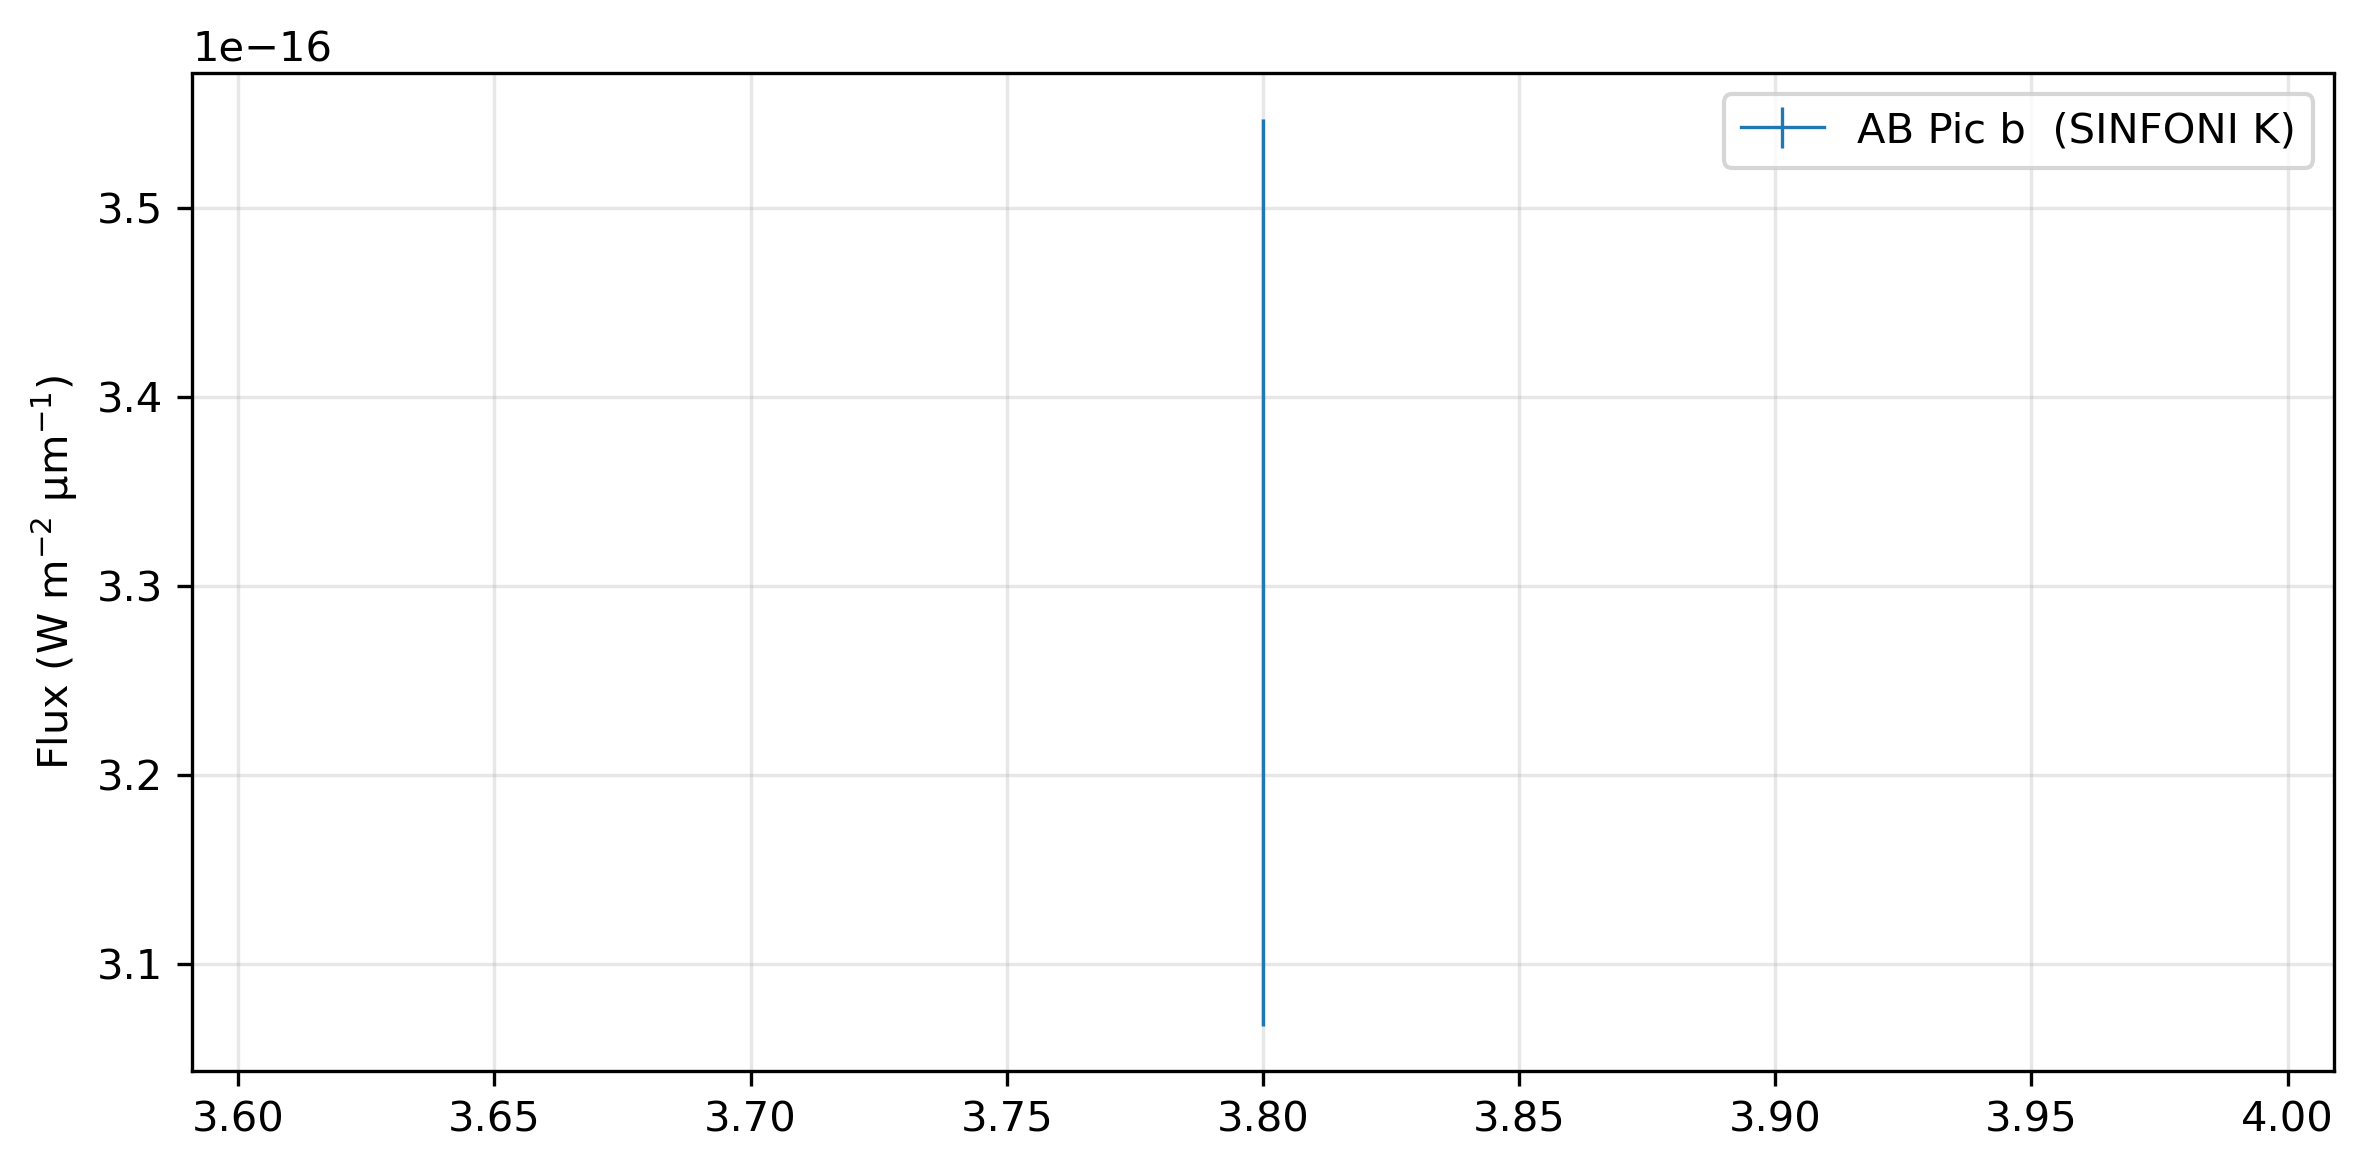

In [18]:
from astropy.table import Table
import matplotlib.pyplot as plt

table = Table.read(PHOTO_FILE, format="fits")
wav  = table["WAV"].data.astype(float)       # wavelength (µm)
flx  = table["FLX"].data.astype(float)       # flux (W/m²/µm)
err  = table["ERR"].data.astype(float)       # 1-σ uncertainty
ins  = table["INS"].data                     # instrument names
res  = table["RES"].data.astype(float)       # spectral resolution R = λ/Δλ

print(f"Wavelength range : {wav.min():.4f} – {wav.max():.4f} µm")
print(f"Number of points : {len(wav)}")
print(f"Resolution R     : {res.mean():.0f} ± {res.std():.0f}  (mean ± std)")

fig, ax = plt.subplots(figsize=(8, 4), sharex=True, dpi=300)
ax.errorbar(wav, flx, yerr=err, color="C0", lw=0.8, label="AB Pic b  (SINFONI K)")
ax.fill_between(wav, flx - err, flx + err, color="C1", alpha=0.2)
ax.set_ylabel(r"Flux (W m$^{-2}$ µm$^{-1}$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout();

Combined rows: 894 from 7 files


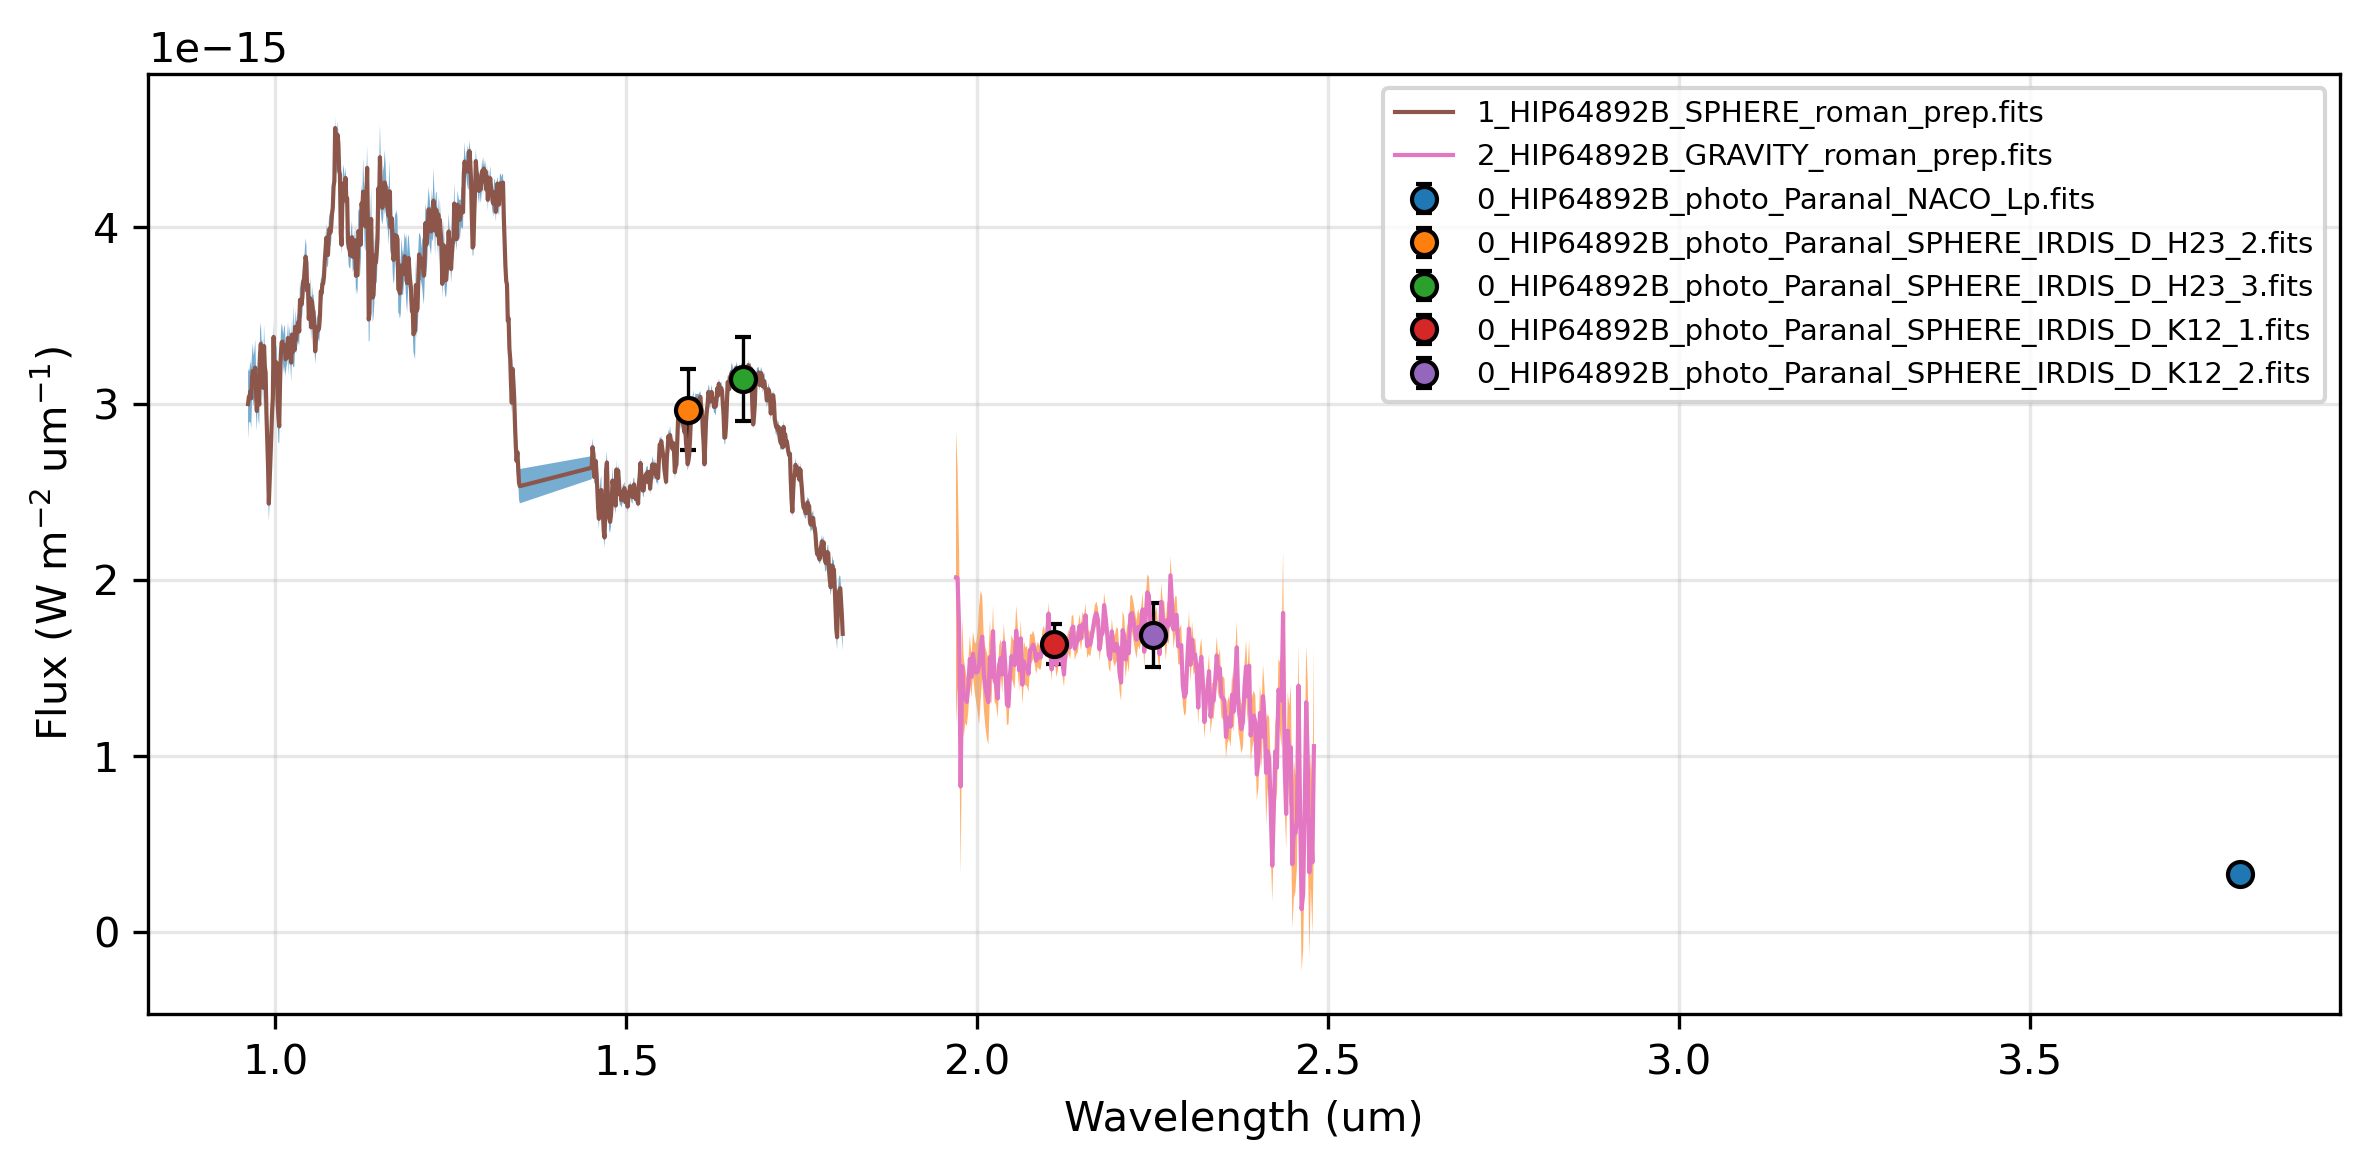

In [26]:
from astropy.io import fits
from astropy.table import Table, vstack
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = TUTORIAL_DIR / "data"
fits_files = sorted(DATA_DIR.glob("*.fits"))
if not fits_files:
    raise FileNotFoundError(f"No .fits files found in {DATA_DIR}")


def _read_fits_table(fpath: Path) -> Table:
    with fits.open(fpath) as hdul:
        table_hdu = next(
            (hdu for hdu in hdul[1:] if getattr(hdu, "columns", None) is not None),
            None,
        )
        if table_hdu is not None:
            return Table(table_hdu.data)

        cols = {}
        for hdu in hdul[1:]:
            name = getattr(hdu, "name", None)
            if not name or hdu.data is None:
                continue
            cols[name.upper()] = np.array(hdu.data).ravel()

    if not cols:
        raise ValueError(f"No table or data HDUs found in {fpath.name}")

    return Table(cols)


def _pick_col(tbl: Table, *names: str):
    for name in names:
        if name in tbl.colnames:
            return np.array(tbl[name])
    return None


def _normalize_table(tbl: Table, source: str, kind: str) -> Table:
    wav = _pick_col(tbl, "WAV", "WAVE", "LAMBDA")
    flx = _pick_col(tbl, "FLX", "FLUX")
    err = _pick_col(tbl, "ERR", "ERROR", "SIGMA")
    res = _pick_col(tbl, "RES")
    ins = _pick_col(tbl, "INS")
    filt = _pick_col(tbl, "FILT")

    if wav is None or flx is None:
        raise ValueError(f"Missing WAV/FLX columns in {source}")

    n = len(wav)
    out = Table()
    out["wav"] = wav.astype(float)
    out["flx"] = flx.astype(float)
    cov = _pick_col(tbl, "COV", "COVAR", "COVARIANCE")
    if err is not None:
        out["err"] = err.astype(float)
    elif cov is not None:
        cov = np.array(cov, dtype=float)
        if cov.ndim == 1:
            out["err"] = np.sqrt(cov)
        else:
            out["err"] = np.sqrt(np.diagonal(cov, axis1=-2, axis2=-1))
    else:
        out["err"] = np.full(n, np.nan)
    out["res"] = res.astype(float) if res is not None else np.full(n, np.nan)
    out["ins"] = ins.astype(str) if ins is not None else np.full(n, "", dtype=object)
    out["filt"] = (
        filt.astype(str) if filt is not None else np.full(n, "", dtype=object)
    )
    out["kind"] = np.full(n, kind, dtype=object)
    out["source"] = np.full(n, source, dtype=object)
    return out


tables = []
per_file = []
for fpath in fits_files:
    if fpath.name.startswith("0_"):
        kind = "photometry"
    elif fpath.name.startswith("1_"):
        kind = "spectroscopy"
    elif fpath.name.startswith("2_"):
        kind = "spectroscopy"
    else:
        continue

    tbl = _read_fits_table(fpath)
    norm = _normalize_table(tbl, fpath.name, kind)
    tables.append(norm)
    per_file.append((fpath.name, kind, norm))

combined_table = vstack(tables, metadata_conflicts="silent")
print(f"Combined rows: {len(combined_table)} from {len(per_file)} files")
combined_table[:5]

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for name, kind, tbl in per_file:
    wav = np.array(tbl["wav"], dtype=float)
    flx = np.array(tbl["flx"], dtype=float)
    err = np.array(tbl["err"], dtype=float)
    order = np.argsort(wav)

    if kind == "photometry":
        ax.errorbar(wav, flx, yerr=err, fmt="o", mec="k", ecolor="k", ms=6, capsize=2, lw=0.8, label=name)
    else:
        ax.plot(wav[order], flx[order], lw=1, label=name)
        if np.isfinite(err).any():
            ax.fill_between(wav[order], flx[order] - err[order], flx[order] + err[order], alpha=0.6)

ax.set_xlabel("Wavelength (um)")
ax.set_ylabel(r"Flux (W m$^{-2}$ um$^{-1}$)")
ax.grid(alpha=0.3)
ax.legend(fontsize=7, ncol=1)
plt.tight_layout();


## Section 3: Configure the analysis

In [ ]:
from ForMoSA.config.global_config import ConfigPath, ConfigAdapt, ConfigInversion, ConfigParameters

# MOSAIC: provide both files in observation_path (order matters — index 0, 1, ...)
config_path = ConfigPath(
    observation_path=[str(SPEC_FILE), str(PHOTO_FILE)],
    adapt_store_path=str(TUTORIAL_DIR / "adapted_grid"),
    result_path=str(TUTORIAL_DIR / "results"),
    model_path=str(GRID_FILE),
)

# Two observations: list parameters per observation where they differ.
# Single-element lists are broadcast to all observations.
config_adapt = ConfigAdapt(
    res_cont=["500", "NA"],   # continuum removal for spectrum; none for photometry
)

config_inversion = ConfigInversion(
    wav_fit=["2.0, 2.45", "1.0, 5.0"],  # per-observation fitting windows
    ns_algo="nestle",
    npoints=300,
    logL_type=["chi2", "chi2"],          # one likelihood type per observation
)

config_params = ConfigParameters(
    par1=["uniform", "1200", "3000"],  # Teff (K)
    par2=["uniform", "2.5", "5.5"],   # log g (dex)
    r=["uniform", "0.5", "3.0"],      # radius (R_Jupiter)
    d=["constant", "19.7"],           # distance (pc) — Gaia
    rv=["uniform", "-100", "100"],    # radial velocity (km/s)
    # MOSAIC alpha parameters: alpha_0 for spectrum, alpha_1 for photometry
    # These account for intercalibration offsets between the two instruments.
    alpha=["uniform", "0.1", "5.0", "uniform", "0.1", "5.0"],
    # Syntax: [prior_0, min_0, max_0, prior_1, min_1, max_1, ...]
)

print("MOSAIC configuration:")
print(f"  Observations : spectrum (idx 0) + photometry (idx 1)")
print(f"  wav_fit      : {config_inversion.wav_fit}")
print(f"  Free params  : par1, par2, r, rv, alpha_0, alpha_1")
print(f"  Fixed        : d = 19.7 pc")


## Section 4: Adapt the grid

In [ ]:
from ForMoSA import Analysis

adapted = False
analysis = Analysis(config_path, adapted=adapted, fitted=False)
if not adapted:
    print("Adapting grid to 2 observations...")
    analysis.adapt(config_adapt, config_inversion)
    print("Done.")


## Section 5: Run the nested sampling fit

In [ ]:
from ForMoSA.config.global_config import Config_NS

config_ns = Config_NS()
print(f"Running {config_inversion.ns_algo} with {config_inversion.npoints} live points...")
analysis.nested_sampling(config_params, config_adapt, config_inversion, config_NS=config_ns)
print("Fit complete.")


## Section 6: Results

In [ ]:
analysis.plot(analysis.ns.results)
print(analysis.ns.results.summary(sigma=1))


## Section 7: INI file alternative

In [ ]:
from ForMoSA.config.global_config import ConfigGenerator
ConfigGenerator().save(str(TUTORIAL_DIR), "config.ini")
print(f"Template: {TUTORIAL_DIR / 'config.ini'}")
print("Edit and load with ConfigLoader — see Tutorial 1 Section 7 for the pattern.")


## Section 8: Next steps

- **Tutorial 5 — Advanced plotting:** Use the results from this (or Tutorial 2)
  to explore every ForMoSA plot in depth. No fitting required.
- **Tutorial 6 — Cluster / MPI deployment:** Scale up to 300+ live points
  using PyMultiNest on an HPC cluster.
